In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01

# Paths - using pre-split data to avoid leakage
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = os.path.join(split_base_path, "train", "images")
val_images_path = os.path.join(split_base_path, "val", "images")
test_images_path = os.path.join(split_base_path, "test", "images")

train_csv_path = os.path.join(split_base_path, "train", "metadata_train.csv")
val_csv_path = os.path.join(split_base_path, "val", "metadata_val.csv")
test_csv_path = os.path.join(split_base_path, "test", "metadata_test.csv")

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# %% Load Pre-Split Data

# Also load original data for before/after comparison 
original_csv_path = "./nodule_dataset21/cxr_images/proccessed_data/metadata.csv"

print("Loading metadata...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Try to load original data
try:
    original_df = pd.read_csv(original_csv_path)
    has_original = True
    print(f"Original dataset: {len(original_df)} samples")
except:
    has_original = False
    print("Original metadata not found, skipping before/after comparison")

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Combine all splits for total distribution
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"Total (combined): {len(combined_df)} samples")

# %% Beautiful color palette
color_negative = '#667eea'  # Soft purple
color_positive = '#f093fb'  # Soft pink
colors = [color_negative, color_positive]

# %% Figure 1: Before vs After Upsampling (if original data exists)
if has_original:
    fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig1.patch.set_facecolor('white')
    
    # Original distribution - Bar
    original_counts = original_df['label'].value_counts().sort_index()
    axes[0, 0].bar(['No Nodule', 'Nodule'], original_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[0, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[0, 0].set_title('Original Dataset (Before Split & Upsample)', fontsize=15, fontweight='bold', pad=15)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].set_facecolor('#ffffff')
    for i, v in enumerate(original_counts.values):
        axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # Original distribution - Pie
    wedges, texts, autotexts = axes[0, 1].pie(original_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[0, 1].set_title('Original Distribution (%)', fontsize=15, fontweight='bold', pad=15)
    
    # After split & upsample - Bar
    combined_counts = combined_df['label'].value_counts().sort_index()
    axes[1, 0].bar(['No Nodule', 'Nodule'], combined_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[1, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[1, 0].set_title('After Split & Upsample (All Splits Combined)', fontsize=15, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].set_facecolor('#ffffff')
    for i, v in enumerate(combined_counts.values):
        axes[1, 0].text(i, v + 100, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # After split & upsample - Pie
    wedges, texts, autotexts = axes[1, 1].pie(combined_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[1, 1].set_title('After Split & Upsample (%)', fontsize=15, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.savefig('before_after_split_upsample.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print("\n✓ Before/After comparison saved to 'before_after_split_upsample.png'")

Loading metadata...
Original metadata not found, skipping before/after comparison
Train: 5725 samples
Val: 782 samples
Test: 785 samples
Total (combined): 7292 samples


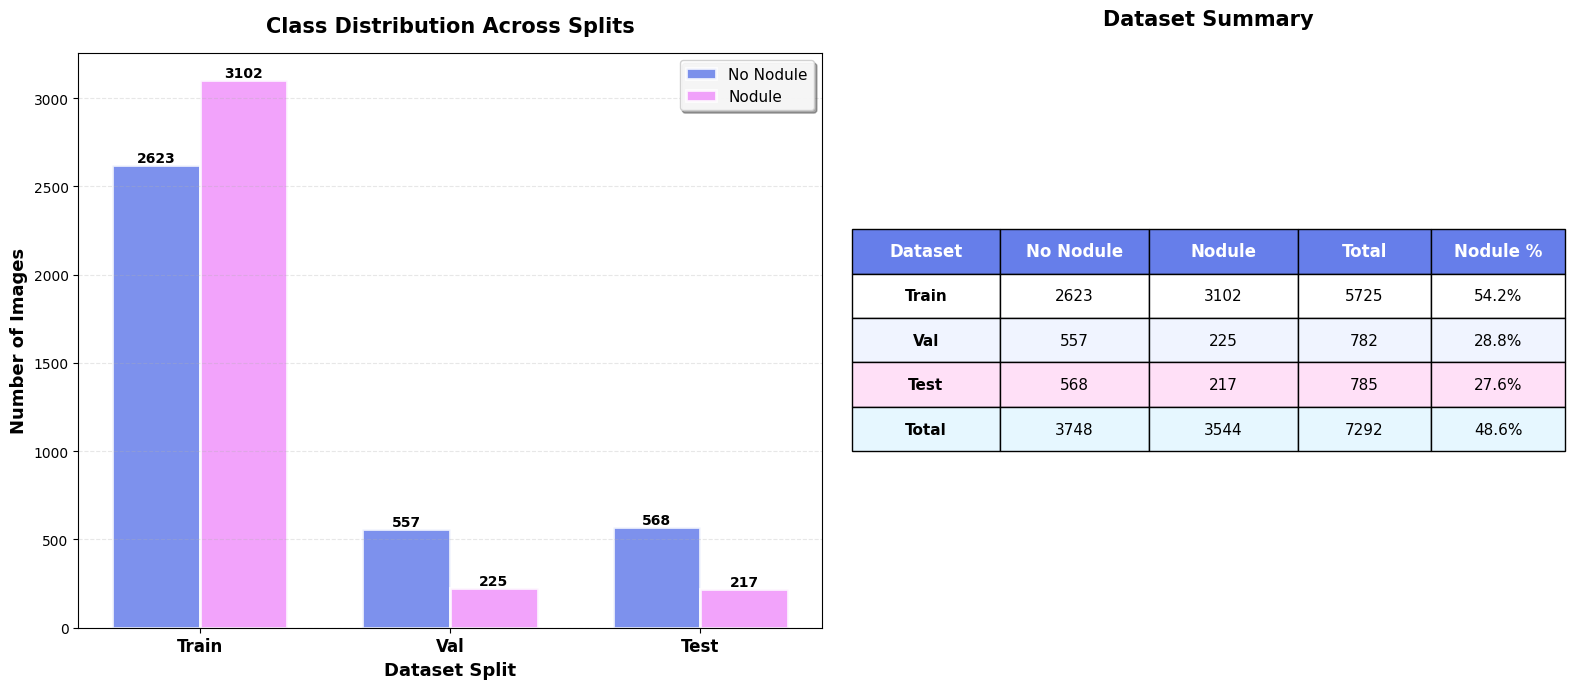

✓ Split distribution saved to 'split_distribution.png'


In [5]:
# %% Figure 2: Train/Val/Test Distribution
fig2, axes = plt.subplots(1, 2, figsize=(16, 7))
fig2.patch.set_facecolor('white')

# Grouped bar chart
splits_data = {
    'Train': train_df['label'].value_counts().sort_index(),
    'Val': val_df['label'].value_counts().sort_index(),
    'Test': test_df['label'].value_counts().sort_index()
}

x = np.arange(len(splits_data))
width = 0.35
bars1 = axes[0].bar(x - width/2, [splits_data[k][0] for k in splits_data.keys()], 
                    width, label='No Nodule', color=color_negative, alpha=0.85, 
                    edgecolor='white', linewidth=2)
bars2 = axes[0].bar(x + width/2, [splits_data[k][1] for k in splits_data.keys()], 
                    width, label='Nodule', color=color_positive, alpha=0.85, 
                    edgecolor='white', linewidth=2)

axes[0].set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
axes[0].set_title('Class Distribution Across Splits', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_data.keys(), fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11, framealpha=0.9, shadow=True)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_facecolor('#ffffff')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Summary table
summary_data = []
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df), ('Total', combined_df)]:
    no_nodule = (split_df['label'] == 0).sum()
    nodule = (split_df['label'] == 1).sum()
    total = len(split_df)
    nodule_pct = f"{nodule/total*100:.1f}%" if total > 0 else "0%"
    summary_data.append([split_name, no_nodule, nodule, total, nodule_pct])

if has_original:
    # Add original row at the top
    orig_no_nodule = (original_df['label'] == 0).sum()
    orig_nodule = (original_df['label'] == 1).sum()
    orig_total = len(original_df)
    orig_pct = f"{orig_nodule/orig_total*100:.1f}%"
    summary_data.insert(0, ['Original', orig_no_nodule, orig_nodule, orig_total, orig_pct])

axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=summary_data,
                      colLabels=['Dataset', 'No Nodule', 'Nodule', 'Total', 'Nodule %'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.2, 0.2, 0.2, 0.18, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header with gradient
for i in range(5):
    table[(0, i)].set_facecolor('#667eea')
    table[(0, i)].set_text_props(weight='bold', color='white', size=12)

# Alternate row colors
row_colors = ['#ffffff', '#f0f4ff', '#ffe0f7', '#e6f7ff', '#e8f5e9', '#fff3e0']
for i in range(1, len(summary_data) + 1):
    for j in range(5):
        table[(i, j)].set_facecolor(row_colors[(i-1) % len(row_colors)])
        table[(i, j)].set_text_props(weight='normal' if j > 0 else 'bold')

axes[1].set_title('Dataset Summary', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Split distribution saved to 'split_distribution.png'")

In [6]:
# %% Print detailed statistics
print("\n" + "="*70)
print("📊 DETAILED STATISTICS")
print("="*70)

if has_original:
    print("\nORIGINAL DATASET (Before Split):")
    print(f"   Total images: {len(original_df)}")
    print(f"   No Nodule (0): {original_counts[0]:,} ({original_counts[0]/len(original_df)*100:.1f}%)")
    print(f"   Nodule (1): {original_counts[1]:,} ({original_counts[1]/len(original_df)*100:.1f}%)")
    print(f"   Imbalance ratio: 1:{original_counts[0]/original_counts[1]:.2f}")

print("\nAFTER SPLIT & UPSAMPLE:")
print(f"   Total images (combined): {len(combined_df)}")
combined_counts = combined_df['label'].value_counts().sort_index()
print(f"   No Nodule (0): {combined_counts[0]:,} ({combined_counts[0]/len(combined_df)*100:.1f}%)")
print(f"   Nodule (1): {combined_counts[1]:,} ({combined_counts[1]/len(combined_df)*100:.1f}%)")
print(f"   Imbalance ratio: 1:{combined_counts[0]/combined_counts[1]:.2f}")

print("\nINDIVIDUAL SPLITS:")
train_counts = train_df['label'].value_counts().sort_index()
print(f"\n   Training Set ({len(train_df)} images):")
print(f"      No Nodule: {train_counts[0]:,} ({train_counts[0]/len(train_df)*100:.1f}%)")
print(f"      Nodule: {train_counts[1]:,} ({train_counts[1]/len(train_df)*100:.1f}%)")

val_counts = val_df['label'].value_counts().sort_index()
print(f"\n   Validation Set ({len(val_df)} images):")
print(f"      No Nodule: {val_counts[0]:,} ({val_counts[0]/len(val_df)*100:.1f}%)")
print(f"      Nodule: {val_counts[1]:,} ({val_counts[1]/len(val_df)*100:.1f}%)")

test_counts = test_df['label'].value_counts().sort_index()
print(f"\n   Test Set ({len(test_df)} images):")
print(f"      No Nodule: {test_counts[0]:,} ({test_counts[0]/len(test_df)*100:.1f}%)")
print(f"      Nodule: {test_counts[1]:,} ({test_counts[1]/len(test_df)*100:.1f}%)")

print("\n" + "="*70)
print("✨ All visualizations saved successfully!")
print("="*70)


📊 DETAILED STATISTICS

AFTER SPLIT & UPSAMPLE:
   Total images (combined): 7292
   No Nodule (0): 3,748 (51.4%)
   Nodule (1): 3,544 (48.6%)
   Imbalance ratio: 1:1.06

INDIVIDUAL SPLITS:

   Training Set (5725 images):
      No Nodule: 2,623 (45.8%)
      Nodule: 3,102 (54.2%)

   Validation Set (782 images):
      No Nodule: 557 (71.2%)
      Nodule: 225 (28.8%)

   Test Set (785 images):
      No Nodule: 568 (72.4%)
      Nodule: 217 (27.6%)

✨ All visualizations saved successfully!


In [5]:
# Create datasets with bbox
train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True, target_size=IMAGE_SIZE)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True, target_size=IMAGE_SIZE)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True, target_size=IMAGE_SIZE)

# Dataloaders remain the same
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

In [8]:
import torch.nn as nn

class ResNetWithBBox(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(ResNetWithBBox, self).__init__()
        # Load pretrained ResNet50
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)  # num_classes=0 removes the head
        
        # Get feature dimension
        feature_dim = self.backbone.num_features  # 2048 for ResNet50
        
        # Classification head
        self.classifier = nn.Linear(feature_dim, num_classes)
        
        # Bbox regression head
        self.bbox_regressor = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4)  # [x, y, w, h]
        )
        
    def forward(self, x):
        # Extract features
        features = self.backbone(x)
        
        # Classification output
        class_logits = self.classifier(features)
        
        # Bbox regression output
        bbox_pred = self.bbox_regressor(features)
        
        return class_logits, bbox_pred

In [9]:
print("\nInitializing ResNet-50 model with bbox regression...")
model = ResNetWithBBox(num_classes=2, pretrained=True)
model = model.to(device)

# Loss functions
criterion_cls = nn.CrossEntropyLoss()
criterion_bbox = nn.SmoothL1Loss()  # Smooth L1 for bbox regression

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Bbox loss weight
BBOX_LOSS_WEIGHT = 1.0  # You can tune this


Initializing ResNet-50 model with bbox regression...


In [10]:
# %% Training Functions
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
def train_epoch(model, loader, criterion_cls, criterion_bbox, optimizer, device, bbox_weight=1.0):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_bbox_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        optimizer.zero_grad()
        class_logits, bbox_pred = model(images)
        
        # Classification loss
        cls_loss = criterion_cls(class_logits, labels)
        
        # Bbox regression loss (only for positive samples)
        bbox_loss = criterion_bbox(bbox_pred, bboxes)
        
        # Combined loss
        loss = cls_loss + bbox_weight * bbox_loss
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_cls_loss += cls_loss.item()
        running_bbox_loss += bbox_loss.item()
        
        probs = torch.softmax(class_logits, dim=1)
        _, predicted = class_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({
            'loss': running_loss/len(loader), 
            'cls_loss': running_cls_loss/len(loader),
            'bbox_loss': running_bbox_loss/len(loader),
            'acc': 100.*correct/total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

def validate(model, loader, criterion_cls, criterion_bbox, device, bbox_weight=1.0):
    model.eval()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_bbox_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
            
            class_logits, bbox_pred = model(images)
            
            cls_loss = criterion_cls(class_logits, labels)
            bbox_loss = criterion_bbox(bbox_pred, bboxes)
            loss = cls_loss + bbox_weight * bbox_loss
            
            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_bbox_loss += bbox_loss.item()
            
            probs = torch.softmax(class_logits, dim=1)
            _, predicted = class_logits.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs, binary_precision, binary_recall, binary_f1, binary_auc

In [11]:
# Check for overlap
train_files = set(train_df['img_name'])
val_files = set(val_df['img_name'])
test_files = set(test_df['img_name'])

print(f"Train ∩ Val: {len(train_files & val_files)}")
print(f"Train ∩ Test: {len(train_files & test_files)}")
print(f"Val ∩ Test: {len(val_files & test_files)}")
# Should all be 0

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [12]:
# %% Training Loop
print("\nStarting training...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_precision': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_precision': []
}

best_val_acc = 0.0
best_model_path = 'best_resnet_nodule_model(NEW).pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc, train_preds, train_labels, train_probs = train_epoch(
        model, train_loader, criterion_cls, criterion_bbox, optimizer, device, BBOX_LOSS_WEIGHT)
    
    # Calculate train metrics
    from sklearn.metrics import precision_score
    train_auc = roc_auc_score(train_labels, train_probs)
    train_precision = precision_score(train_labels, train_preds, average='binary', zero_division=0)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs, val_precision, val_recall, val_f1, val_auc = validate(
        model, val_loader, criterion_cls, criterion_bbox, device, BBOX_LOSS_WEIGHT)
    
    # Calculate val metrics
    val_auc = roc_auc_score(val_labels, val_probs)
    val_precision = precision_score(val_labels, val_preds, average='binary', zero_division=0)
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_precision'].append(train_precision)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_precision)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train AUC: {train_auc:.4f}, Train Precision: {train_precision:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f}, Val Precision: {val_precision:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
        }, best_model_path)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f})")

print("\nTraining completed!")


Starting training...

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:11<00:00,  4.22it/s]


Train Loss: 0.5113, Train Acc: 74.46%, Train AUC: 0.8517, Train Precision: 0.7091
Val Loss: 0.2918, Val Acc: 87.60%, Val AUC: 0.9549, Val Precision: 0.8951
LR: 0.000100
✓ Saved best model (Val Acc: 87.60%, Val AUC: 0.9549)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:11<00:00,  4.19it/s]


Train Loss: 0.2726, Train Acc: 90.10%, Train AUC: 0.9586, Train Precision: 0.9046
Val Loss: 0.2024, Val Acc: 92.97%, Val AUC: 0.9827, Val Precision: 0.8220
LR: 0.000098
✓ Saved best model (Val Acc: 92.97%, Val AUC: 0.9827)

Epoch 3/25
--------------------------------------------------


...

Train Loss: 0.0273, Train Acc: 99.42%, Train AUC: 0.9998, Train Precision: 0.9948
Val Loss: 0.1285, Val Acc: 95.01%, Val AUC: 0.9930, Val Precision: 0.9697
LR: 0.000002

Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.50it/s]


Train Loss: 0.0268, Train Acc: 99.30%, Train AUC: 0.9998, Train Precision: 0.9939
Val Loss: 0.1027, Val Acc: 96.29%, Val AUC: 0.9924, Val Precision: 0.9537
LR: 0.000000

Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.47it/s]

Train Loss: 0.0311, Train Acc: 99.30%, Train AUC: 0.9996, Train Precision: 0.9936
Val Loss: 0.1020, Val Acc: 96.68%, Val AUC: 0.9925, Val Precision: 0.9585
LR: 0.000000

Training completed!


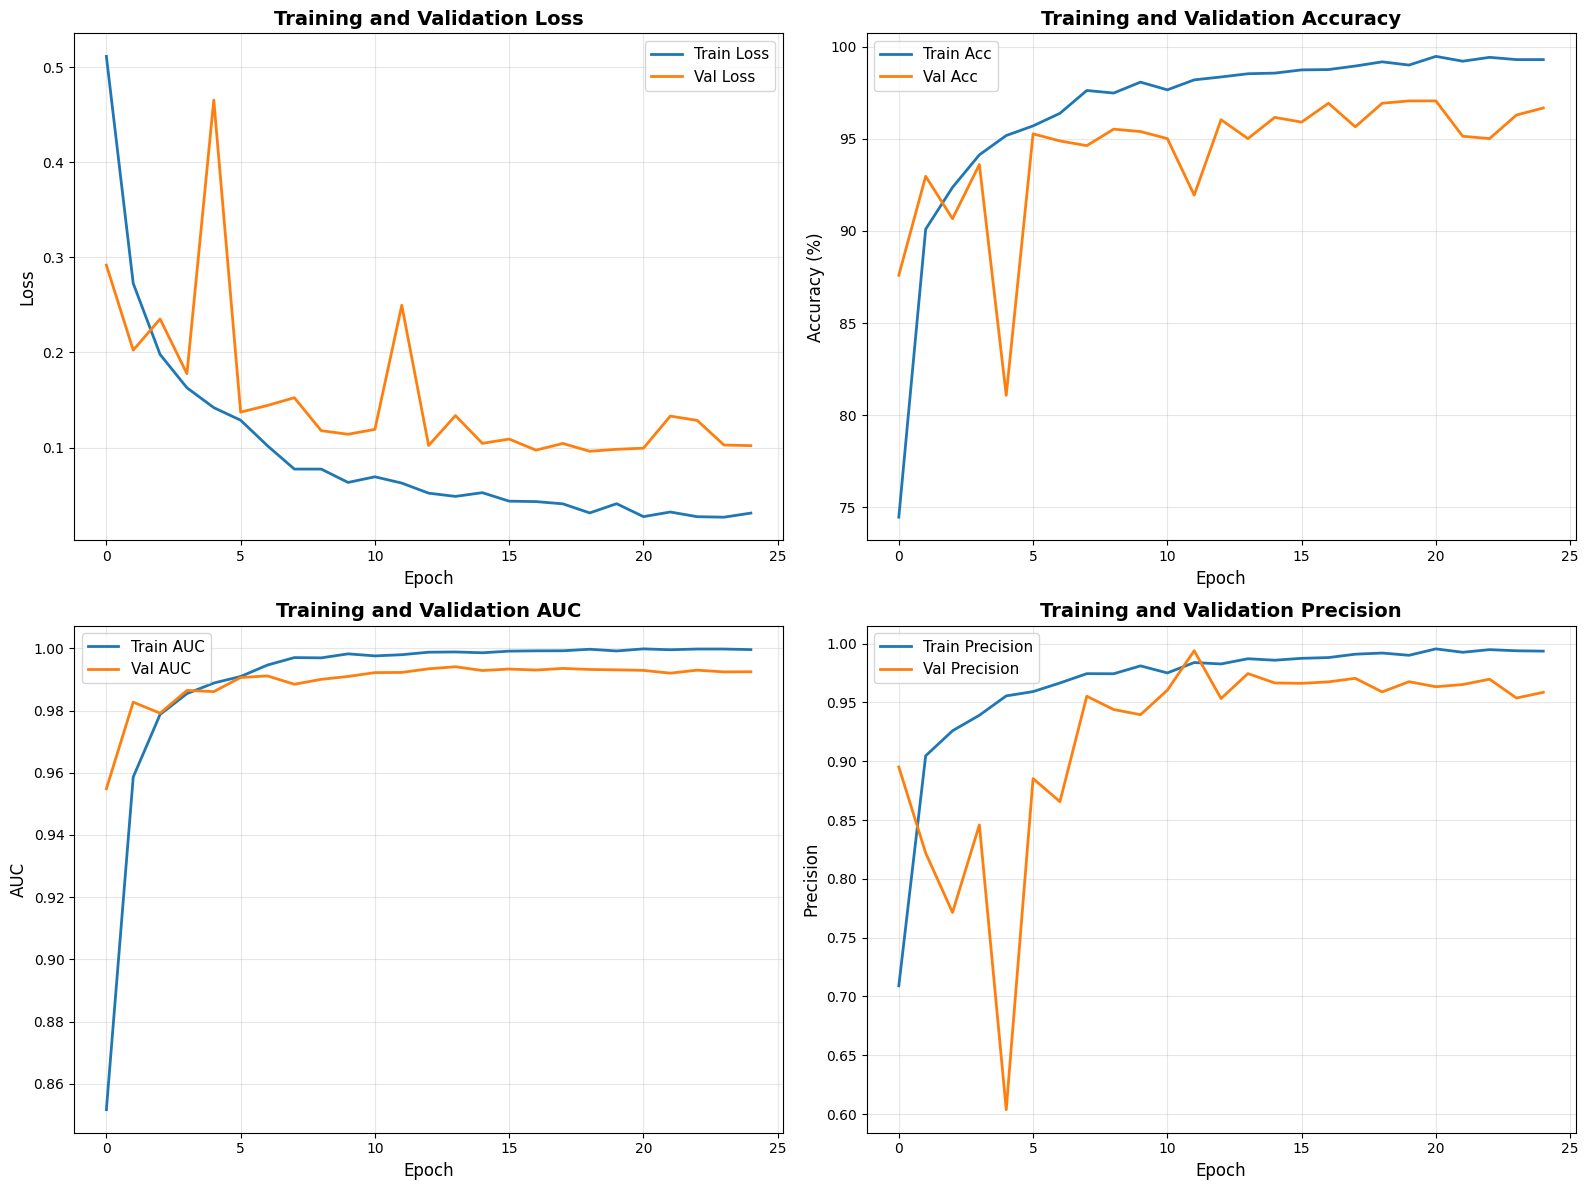

In [13]:
# %% Plot Training History
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# AUC plot
ax3.plot(history['train_auc'], label='Train AUC', linewidth=2)
ax3.plot(history['val_auc'], label='Val AUC', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('AUC', fontsize=12)
ax3.set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Precision plot
ax4.plot(history['train_precision'], label='Train Precision', linewidth=2)
ax4.plot(history['val_precision'], label='Val Precision', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Training and Validation Precision', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [14]:
# %% Evaluate Bounding Box Performance on Test Set
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

def calculate_iou(pred_bbox, gt_bbox):
    """
    Calculate IoU between predicted and ground truth bboxes
    Both bboxes are in format [x, y, w, h] (normalized [0, 1])
    """
    # Convert to [x1, y1, x2, y2] format
    pred_x1 = pred_bbox[0]
    pred_y1 = pred_bbox[1]
    pred_x2 = pred_bbox[0] + pred_bbox[2]
    pred_y2 = pred_bbox[1] + pred_bbox[3]
    
    gt_x1 = gt_bbox[0]
    gt_y1 = gt_bbox[1]
    gt_x2 = gt_bbox[0] + gt_bbox[2]
    gt_y2 = gt_bbox[1] + gt_bbox[3]
    
    # Calculate intersection
    inter_x1 = max(pred_x1, gt_x1)
    inter_y1 = max(pred_y1, gt_y1)
    inter_x2 = min(pred_x2, gt_x2)
    inter_y2 = min(pred_y2, gt_y2)
    
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    # Calculate union
    pred_area = pred_bbox[2] * pred_bbox[3]
    gt_area = gt_bbox[2] * gt_bbox[3]
    union_area = pred_area + gt_area - inter_area
    
    # Calculate IoU
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

def pointing_game_accuracy(pred_bbox, gt_bbox):
    """
    Check if the center of predicted bbox falls within ground truth bbox
    Returns 1 if hit, 0 if miss
    """
    # Center of predicted bbox
    pred_center_x = pred_bbox[0] + pred_bbox[2] / 2
    pred_center_y = pred_bbox[1] + pred_bbox[3] / 2
    
    # Check if center is inside ground truth bbox
    gt_x1 = gt_bbox[0]
    gt_y1 = gt_bbox[1]
    gt_x2 = gt_bbox[0] + gt_bbox[2]
    gt_y2 = gt_bbox[1] + gt_bbox[3]
    
    hit = (gt_x1 <= pred_center_x <= gt_x2) and (gt_y1 <= pred_center_y <= gt_y2)
    return 1 if hit else 0



In [15]:
print("\nLoading best model for testing...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Collect predictions
all_class_preds = []
all_class_labels = []
all_class_probs = []
all_bbox_preds = []
all_bbox_gts = []
all_ious = []
all_pointing_game = []

running_loss = 0.0
correct = 0
total = 0

print("\nEvaluating on test set...")
with torch.no_grad():
    for images, labels, bboxes in tqdm(test_loader, desc='Testing'):
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        class_logits, bbox_pred = model(images)
        
        # Classification loss
        cls_loss = criterion_cls(class_logits, labels)
        bbox_loss = criterion_bbox(bbox_pred, bboxes)
        loss = cls_loss + BBOX_LOSS_WEIGHT * bbox_loss
        
        running_loss += loss.item()
        
        # Classification metrics
        probs = torch.softmax(class_logits, dim=1)
        _, predicted = class_logits.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_class_preds.extend(predicted.cpu().numpy())
        all_class_labels.extend(labels.cpu().numpy())
        all_class_probs.extend(probs[:, 1].cpu().numpy())
        
        # Bbox metrics
        bbox_pred_np = bbox_pred.cpu().numpy()
        bbox_gt_np = bboxes.cpu().numpy()
        
        all_bbox_preds.extend(bbox_pred_np)
        all_bbox_gts.extend(bbox_gt_np)
        
        # Calculate IoU and Pointing Game for each sample
        for pred, gt in zip(bbox_pred_np, bbox_gt_np):
            iou = calculate_iou(pred, gt)
            pg = pointing_game_accuracy(pred, gt)
            all_ious.append(iou)
            all_pointing_game.append(pg)

# Calculate metrics
test_loss = running_loss / len(test_loader)
test_acc = 100. * correct / total

# Classification metrics
test_auc = roc_auc_score(all_class_labels, all_class_probs)
test_precision = precision_score(all_class_labels, all_class_preds, average='binary', zero_division=0)
test_recall = recall_score(all_class_labels, all_class_preds, average='binary', zero_division=0)
test_f1 = f1_score(all_class_labels, all_class_preds, average='binary', zero_division=0)

# Bbox metrics
mean_iou = np.mean(all_ious)
median_iou = np.median(all_ious)
iou_std = np.std(all_ious)
pointing_game_acc = np.mean(all_pointing_game) * 100

# IoU thresholds
iou_50 = np.mean([iou >= 0.5 for iou in all_ious]) * 100  # % of predictions with IoU >= 0.5
iou_75 = np.mean([iou >= 0.75 for iou in all_ious]) * 100  # % of predictions with IoU >= 0.75

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)

print("\nCLASSIFICATION METRICS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print(f"  ROC AUC: {test_auc:.4f}")

print("\nBOUNDING BOX METRICS:")
print(f"  Mean IoU: {mean_iou:.4f}")
print(f"  Median IoU: {median_iou:.4f}")
print(f"  IoU Std Dev: {iou_std:.4f}")
print(f"  IoU@0.5 (% samples): {iou_50:.2f}%")
print(f"  IoU@0.75 (% samples): {iou_75:.2f}%")
print(f"  Pointing Game Accuracy: {pointing_game_acc:.2f}%")

print("\n" + "="*60)

print("\nClassification Report:")
print(classification_report(all_class_labels, all_class_preds, 
                          target_names=['No Nodule', 'Nodule']))

print("\nIoU Distribution:")
iou_bins = [0, 0.25, 0.5, 0.75, 1.0]
for i in range(len(iou_bins)-1):
    count = sum([iou_bins[i] <= iou < iou_bins[i+1] for iou in all_ious])
    percentage = (count / len(all_ious)) * 100
    print(f"  IoU [{iou_bins[i]:.2f} - {iou_bins[i+1]:.2f}): {count:4d} samples ({percentage:5.2f}%)")


Loading best model for testing...

Evaluating on test set...


Testing: 100%|██████████| 50/50 [00:13<00:00,  3.77it/s]


TEST SET RESULTS

CLASSIFICATION METRICS:
  Test Loss: 0.1040
  Test Accuracy: 96.94%
  Precision: 0.9531
  Recall: 0.9355
  F1 Score: 0.9442
  ROC AUC: 0.9926

BOUNDING BOX METRICS:
  Mean IoU: 0.0000
  Median IoU: 0.0000
  IoU Std Dev: 0.0001
  IoU@0.5 (% samples): 0.00%
  IoU@0.75 (% samples): 0.00%
  Pointing Game Accuracy: 0.00%


Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.98      0.98      0.98       568
      Nodule       0.95      0.94      0.94       217

    accuracy                           0.97       785
   macro avg       0.96      0.96      0.96       785
weighted avg       0.97      0.97      0.97       785


IoU Distribution:
  IoU [0.00 - 0.25):  785 samples (100.00%)
  IoU [0.25 - 0.50):    0 samples ( 0.00%)
  IoU [0.50 - 0.75):    0 samples ( 0.00%)
  IoU [0.75 - 1.00):    0 samples ( 0.00%)



Visualizing bbox predictions on random test samples...


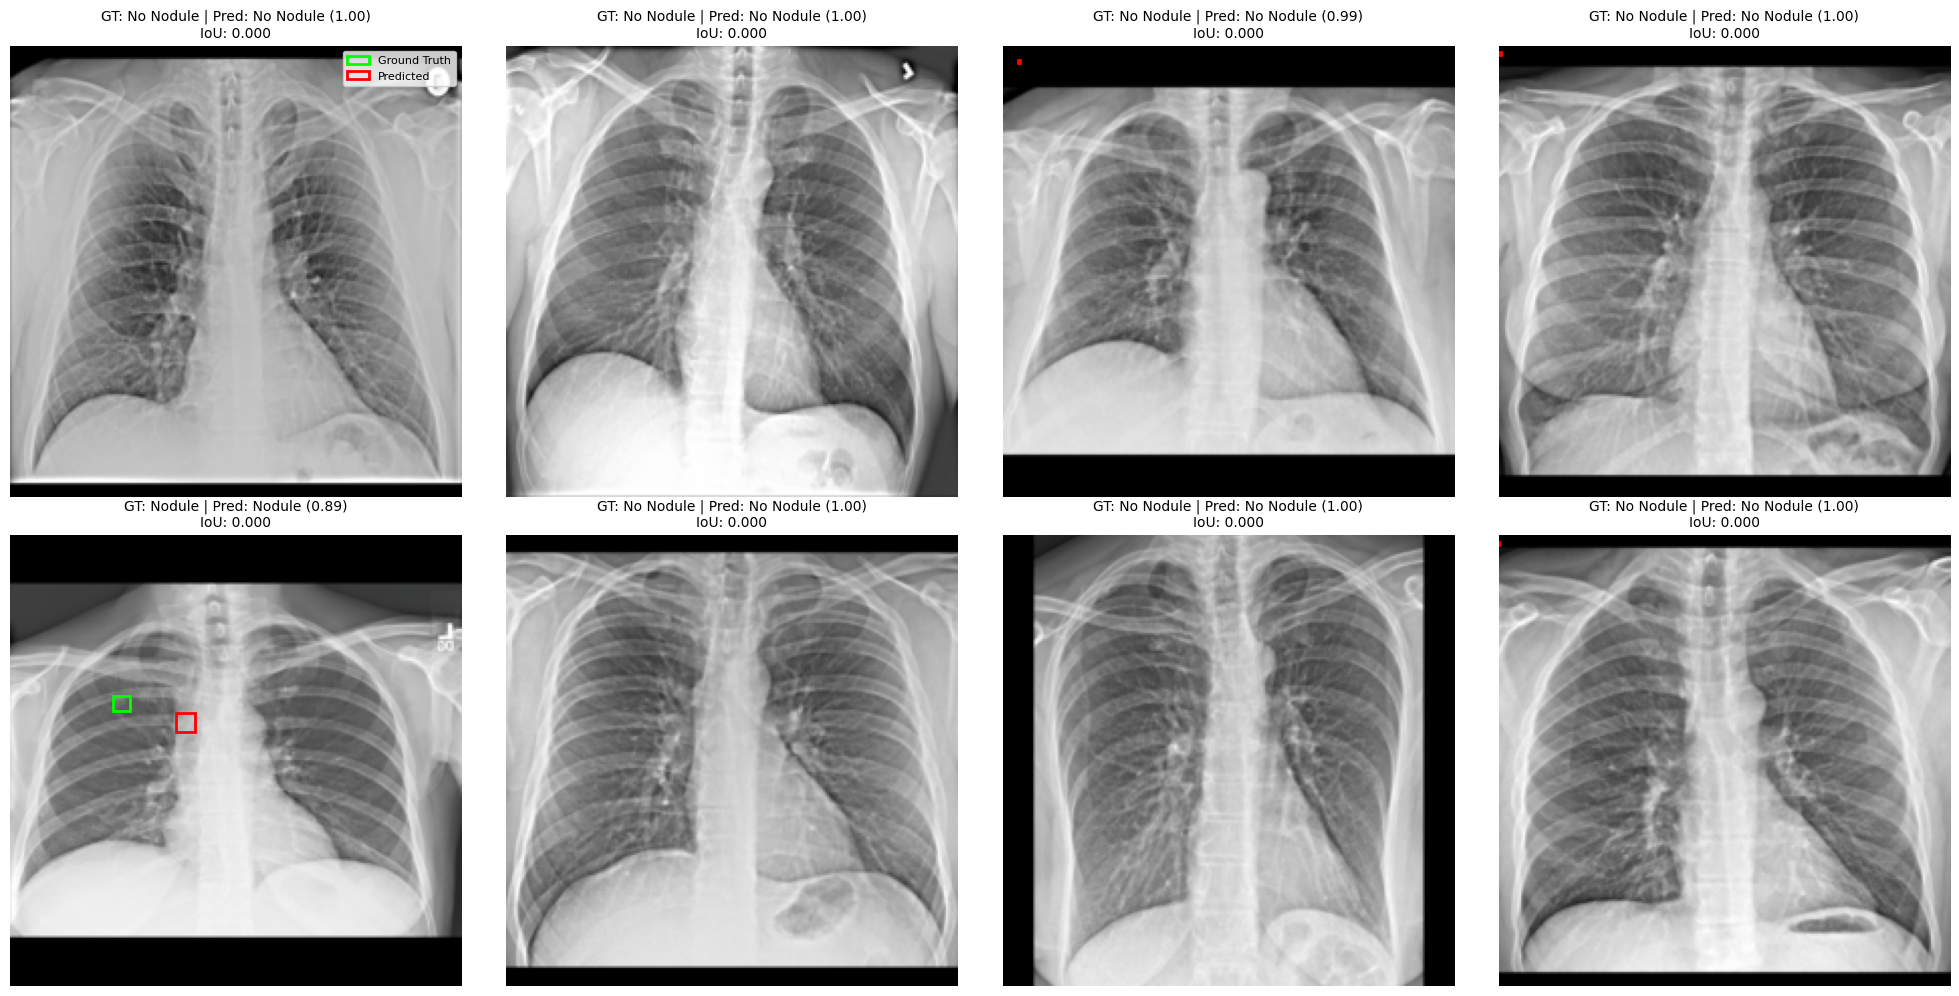

In [35]:
# %% Visualize Bbox Predictions on Random Test Images
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms

def denormalize_image(img_tensor):
    """Denormalize image from ImageNet normalization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def visualize_bbox_prediction(model, dataset, device, num_samples=8):
    """Visualize random samples with ground truth and predicted bboxes"""
    model.eval()
    
    # Randomly select samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label, bbox_gt = dataset[idx]
            
            # Get prediction
            image_batch = image.unsqueeze(0).to(device)
            class_logits, bbox_pred = model(image_batch)
            
            # Get classification result
            probs = torch.softmax(class_logits, dim=1)
            pred_class = class_logits.argmax(1).item()
            pred_prob = probs[0, pred_class].item()
            
            # Get bbox prediction
            bbox_pred = bbox_pred.squeeze(0).cpu().numpy()
            bbox_gt = bbox_gt.numpy()
            
            # Denormalize image for display
            img_display = denormalize_image(image).permute(1, 2, 0).numpy()
            
            # Display image
            ax.imshow(img_display)
            
            # Convert normalized bbox to pixel coordinates (224×224)
            def bbox_to_rect(bbox, color, label):
                x, y, w, h = bbox
                x_pixel = x * IMAGE_SIZE
                y_pixel = y * IMAGE_SIZE
                w_pixel = w * IMAGE_SIZE
                h_pixel = h * IMAGE_SIZE
                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                        linewidth=2, edgecolor=color, facecolor='none',
                                        label=label)
                return rect
            
            # Draw ground truth bbox (green)
            rect_gt = bbox_to_rect(bbox_gt, 'lime', 'Ground Truth')
            ax.add_patch(rect_gt)
            
            # Draw predicted bbox (red)
            rect_pred = bbox_to_rect(bbox_pred, 'red', 'Predicted')
            ax.add_patch(rect_pred)
            
            # Calculate IoU for this sample
            iou = calculate_iou(bbox_pred, bbox_gt)
            
            # Title with classification and bbox info
            class_name = 'Nodule' if label == 1 else 'No Nodule'
            pred_name = 'Nodule' if pred_class == 1 else 'No Nodule'
            title = f'GT: {class_name} | Pred: {pred_name} ({pred_prob:.2f})\nIoU: {iou:.3f}'
            ax.set_title(title, fontsize=10)
            ax.axis('off')
            
            # Add legend only to first subplot
            if idx == indices[0]:
                ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Run visualization
print("\nVisualizing bbox predictions on random test samples...")
visualize_bbox_prediction(model, test_dataset, device, num_samples=8)


Loading pretrained ResNet-50 binary model...
Loaded checkpoint from epoch 24
Previous val_acc: 96.68%
✓ ResNet-50 binary model loaded for GradCAM visualization

GRADCAM VISUALIZATION WITH MULTIPLE BBOXES

Finding positive samples (with nodules) for GradCAM visualization...
Found 165 unique positive patients in test set
Visualizing 8 random positive patients with GradCAM...

Patient: n0456.mha
  Added bbox: pixel=[535, 664, 109, 103]
Found 1 nodule(s)


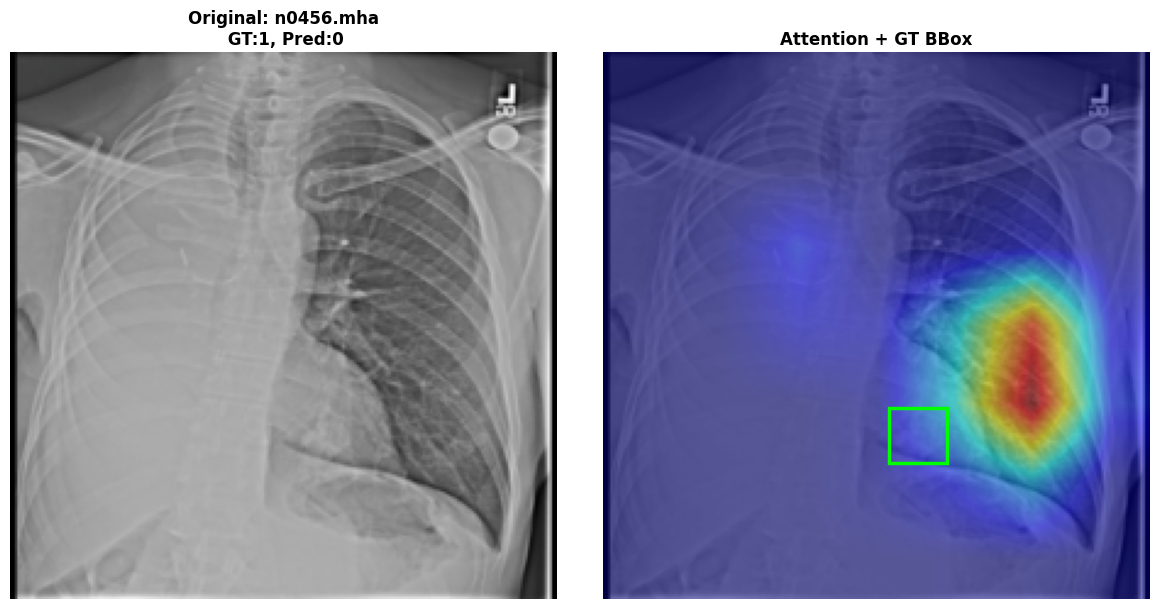

Patient: n0227.mha
  Added bbox: pixel=[190, 137, 68, 69]
Found 1 nodule(s)


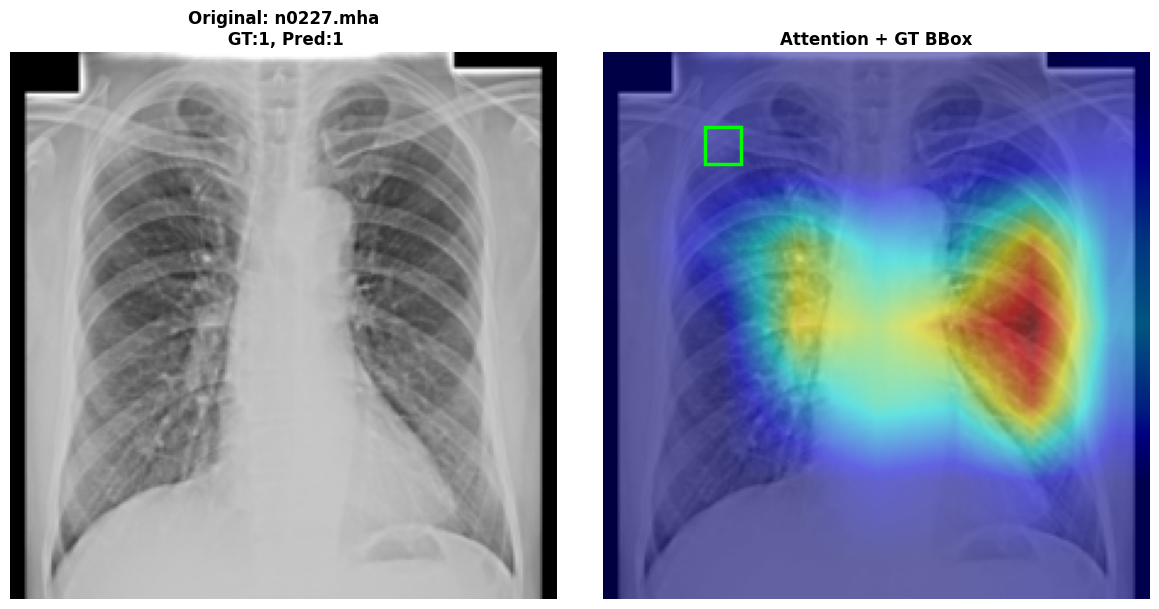

Patient: n0495.mha
  Added bbox: pixel=[330, 704, 60, 57]
  Added bbox: pixel=[674, 552, 81, 75]
  Added bbox: pixel=[159, 612, 40, 49]
Found 3 nodule(s)


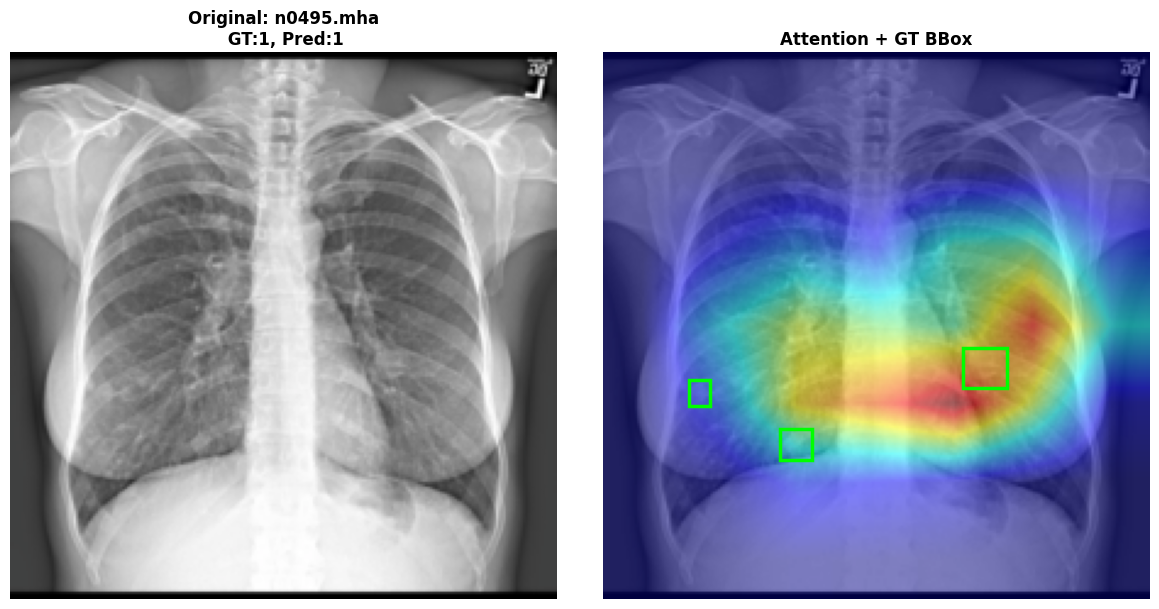

Patient: n0516.mha
  Added bbox: pixel=[320, 427, 93, 83]
Found 1 nodule(s)


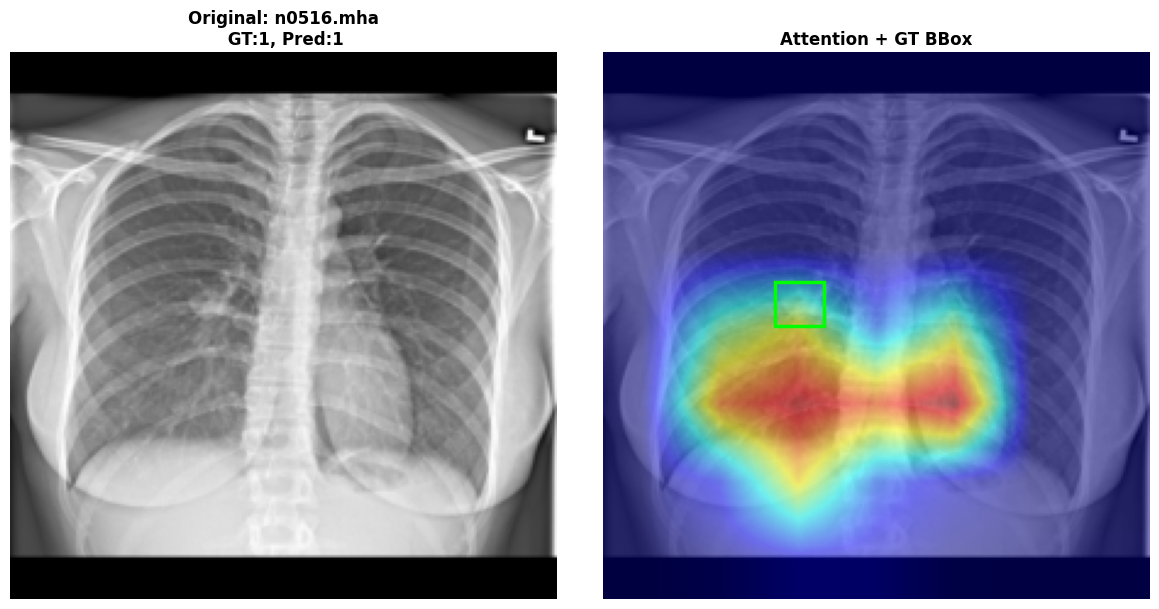

Patient: n1014.mha
  Added bbox: pixel=[204, 310, 82, 94]
  Added bbox: pixel=[183, 482, 30, 61]
  Added bbox: pixel=[251, 507, 94, 105]
Found 3 nodule(s)


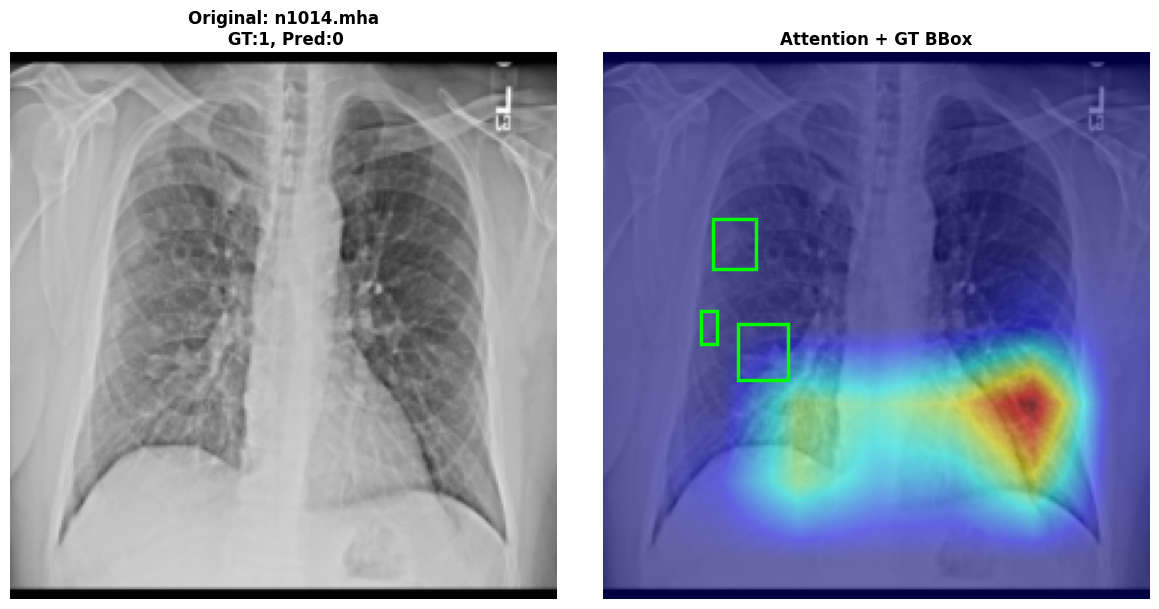

Patient: n0546.mha
  Added bbox: pixel=[286, 646, 45, 50]
  Added bbox: pixel=[198, 684, 53, 47]
  Added bbox: pixel=[169, 474, 30, 31]
Found 3 nodule(s)


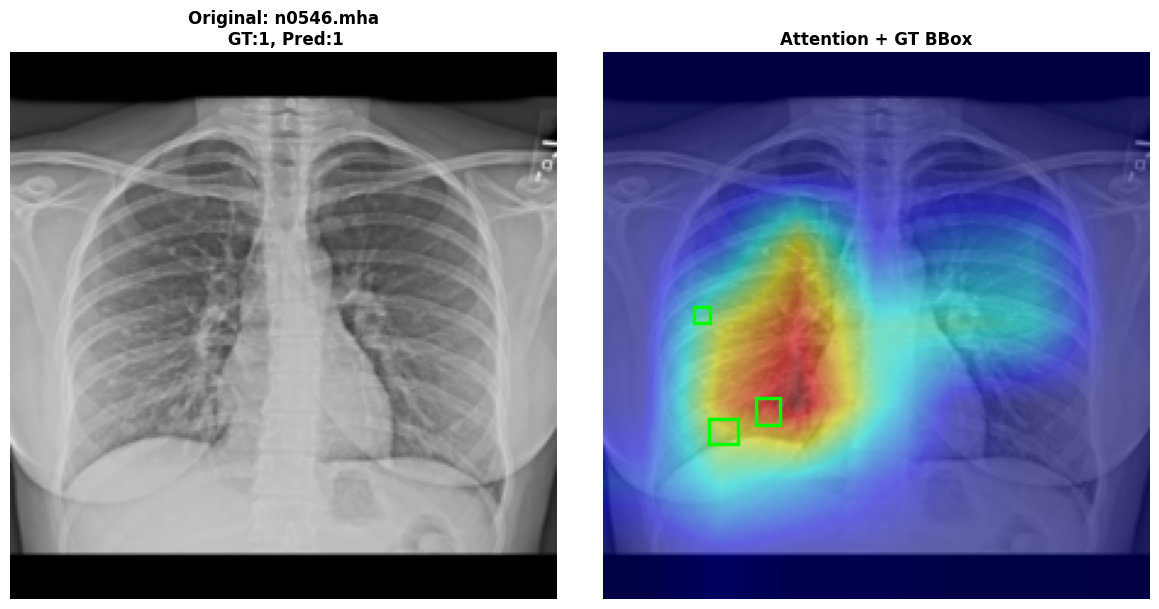

Patient: n0541.mha
  Added bbox: pixel=[832, 601, 53, 55]
Found 1 nodule(s)


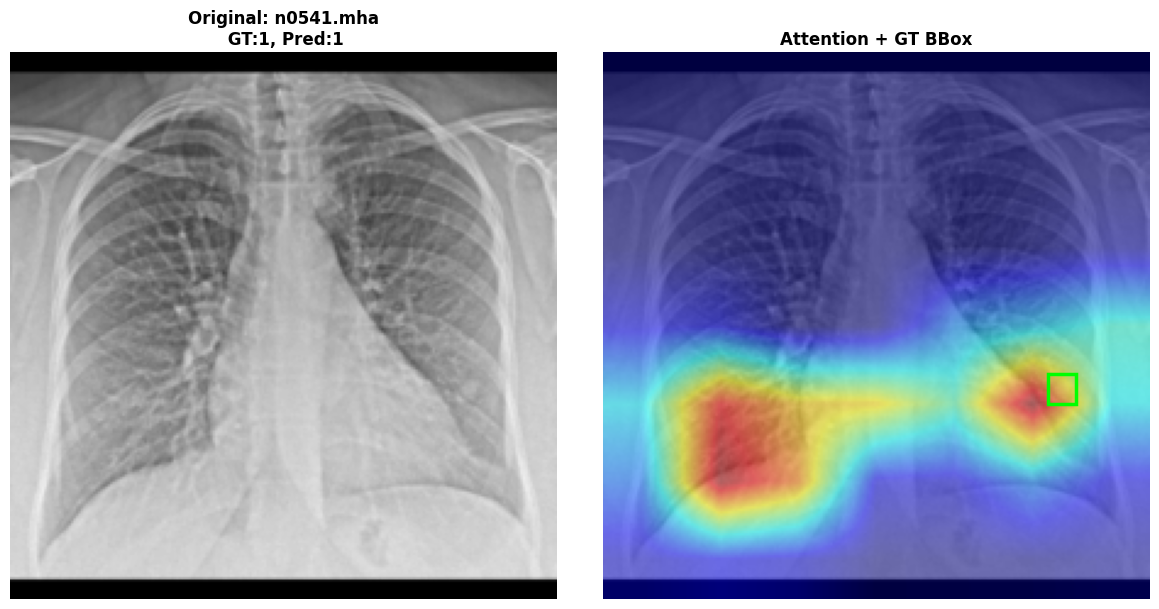

Patient: n0484.mha
  Added bbox: pixel=[217, 744, 75, 69]
Found 1 nodule(s)


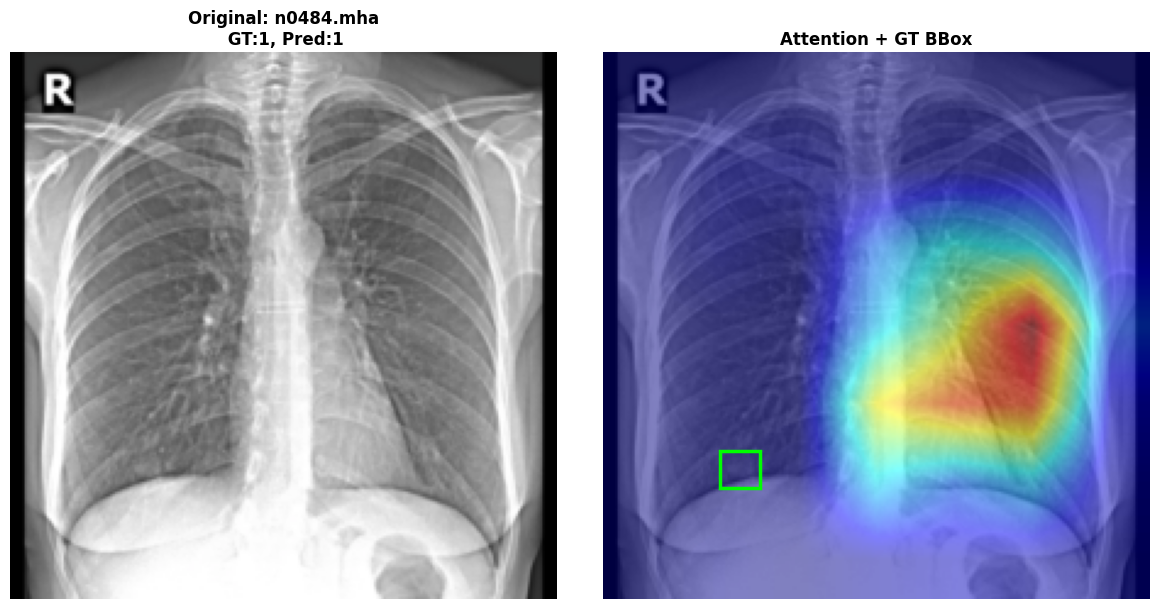


Displayed GradCAM visualizations for 8 unique positive patients
Each visualization shows ALL nodules for that patient


In [16]:
# ============================================================================
# LOAD PRETRAINED RESNET-50 BINARY MODEL FOR GRADCAM
# ============================================================================

print("\nLoading pretrained ResNet-50 binary model...")

# First, define the model architecture (assuming you have this from your training)
from torchvision import models
import torch
import timm
import torch.nn.functional as F
import cv2
import numpy as np

# Create model instance
gradcam_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
gradcam_model = gradcam_model.to(device)

# Load checkpoint
checkpoint_path = "./resnet-50_binary.pth"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

if 'model_state_dict' in checkpoint:
    gradcam_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Previous val_acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    gradcam_model.load_state_dict(checkpoint)
    print("Loaded model weights")

gradcam_model.eval()
print("✓ ResNet-50 binary model loaded for GradCAM visualization")

# ============================================================================
# GRADCAM IMPLEMENTATION
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, class_idx=None):
        """Generate GradCAM heatmap"""
        # Forward pass
        model_output = self.model(input_image)
        
        if class_idx is None:
            class_idx = model_output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = model_output[0, class_idx]
        class_score.backward()
        
        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()

def apply_colormap_on_image(org_img, activation_map, colormap=cv2.COLORMAP_JET, alpha=0.5):
    """Apply heatmap overlay on image"""
    # Resize heatmap to match image size
    heatmap = cv2.resize(activation_map, (org_img.shape[1], org_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Convert org_img to uint8 if needed
    if org_img.dtype != np.uint8:
        org_img = np.uint8(255 * org_img)
    
    # Superimpose heatmap on image
    overlayed_img = cv2.addWeighted(heatmap, alpha, org_img, 1 - alpha, 0)
    
    return overlayed_img

def denormalize_image(img_tensor):
    """Denormalize image tensor"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# ============================================================================
# VISUALIZE GRADCAM WITH MULTIPLE BBOXES PER PATIENT
# ============================================================================

def visualize_gradcam_with_multiple_bboxes(model, dataset, df, device, num_samples=8):
    """Visualize GradCAM on patients with nodules, showing all bboxes per patient"""
    model.eval()
    
    # Get the last convolutional layer of ResNet50
    # For timm ResNet models, access layer4 directly (not model.backbone.layer4)
    target_layer = model.layer4[-1]
    
    # Initialize GradCAM
    gradcam = GradCAM(model, target_layer)
    
    print("\nFinding positive samples (with nodules) for GradCAM visualization...")
    
    # Find unique positive patients
    positive_patients = {}  # {img_name: first_index}
    for i in range(len(dataset)):
        _, label, _ = dataset[i]
        if label == 1:
            img_name = df.iloc[i]['img_name']
            if img_name not in positive_patients:
                positive_patients[img_name] = i
    
    print(f"Found {len(positive_patients)} unique positive patients in test set")
    
    # Randomly select patients
    num_vis = min(num_samples, len(positive_patients))
    if num_vis == 0:
        print("No positive samples found in test set")
        return
    
    selected_patients = np.random.choice(list(positive_patients.keys()), size=num_vis, replace=False)
    print(f"Visualizing {num_vis} random positive patients with GradCAM...\n")
    
    for patient_name in selected_patients:
        # Get the first index for this patient
        idx = positive_patients[patient_name]
        img, label, _ = dataset[idx]
        
        print(f"Patient: {patient_name}")
        
        # Find ALL bboxes for this patient from the dataframe
        patient_rows = df[df['img_name'] == patient_name]
        all_bboxes = []
        
        # Get original image dimensions
        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            img_width = 1024
            img_height = 1024
        
        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                # Normalize bbox coordinates to [0, 1]
                x_norm = row['x'] / img_width
                y_norm = row['y'] / img_height
                w_norm = row['width'] / img_width
                h_norm = row['height'] / img_height
                
                bbox_tensor = torch.tensor([x_norm, y_norm, w_norm, h_norm], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, {row['width']:.0f}, {row['height']:.0f}]")
        
        print(f"Found {len(all_bboxes)} nodule(s)")
        
        # Get prediction and GradCAM
        image_batch = img.unsqueeze(0).to(device)
        class_logits = model(image_batch)
        
        probs = torch.softmax(class_logits, dim=1)
        pred_class = class_logits.argmax(1).item()
        pred_prob = probs[0, pred_class].item()
        
        # Generate GradCAM
        cam = gradcam.generate_cam(image_batch, class_idx=pred_class)
        
        # Denormalize image
        img_display = denormalize_image(img).permute(1, 2, 0).numpy()
        img_display_uint8 = np.uint8(255 * img_display)
        
        # Apply colormap
        overlayed_img = apply_colormap_on_image(img_display_uint8, cam, alpha=0.5)
        
        # Create figure with 2 columns: Original + GradCAM with BBoxes
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # Plot 1: Original Image
        axes[0].imshow(img_display)
        # Format: "Original:\n GT:1, Pred:1"
        axes[0].set_title(
            f'Original: {patient_name}\n GT:{label}, Pred:{pred_class}',
            fontsize=12, fontweight='bold'
        )
        axes[0].axis('off')
        
        # Plot 2: GradCAM with ALL bboxes
        axes[1].imshow(overlayed_img)
        
        # Draw all bboxes
        for bbox in all_bboxes:
            x, y, w, h = bbox.numpy()
            x_pix = x * IMAGE_SIZE
            y_pix = y * IMAGE_SIZE
            w_pix = w * IMAGE_SIZE
            h_pix = h * IMAGE_SIZE
            
            rect = plt.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                fill=False, edgecolor='lime', linewidth=2.5
            )
            axes[1].add_patch(rect)
        
        # Simple title: "Attention + GT BBox"
        axes[1].set_title(
            'Attention + GT BBox',
            fontsize=12, fontweight='bold'
        )
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    print(f"\n{'='*80}")
    print(f"Displayed GradCAM visualizations for {num_vis} unique positive patients")
    print(f"Each visualization shows ALL nodules for that patient")
    print(f"{'='*80}")

# Run GradCAM visualization
print("\n" + "=" * 80)
print("GRADCAM VISUALIZATION WITH MULTIPLE BBOXES")
print("=" * 80)
visualize_gradcam_with_multiple_bboxes(gradcam_model, test_dataset, test_df, device, num_samples=8)


Loading pretrained ResNet-50 binary model...
Loaded checkpoint from epoch 24
Previous val_acc: 96.68%
✓ ResNet-50 binary model loaded for GradCAM visualization

GRADCAM VISUALIZATION FOR SPECIFIC PATIENTS

Searching for specific patients: ['n0368.mha', 'n0315.mha']
✓ Found 2 patient(s): ['n0315.mha', 'n0368.mha']

Patient: n0315.mha
  Added bbox: pixel=[771, 592, 57, 48]
Found 1 nodule(s)
Ground truth label: Nodule
Prediction: Nodule (confidence: 1.000)


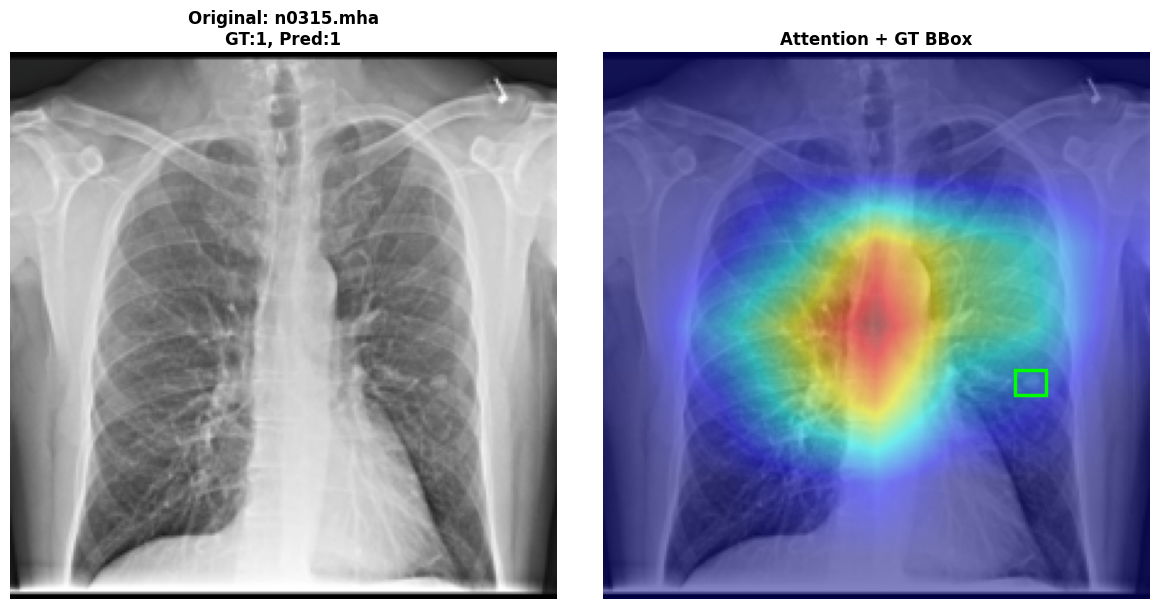


Patient: n0368.mha
  Added bbox: pixel=[175, 482, 38, 38]
Found 1 nodule(s)
Ground truth label: Nodule
Prediction: Nodule (confidence: 1.000)


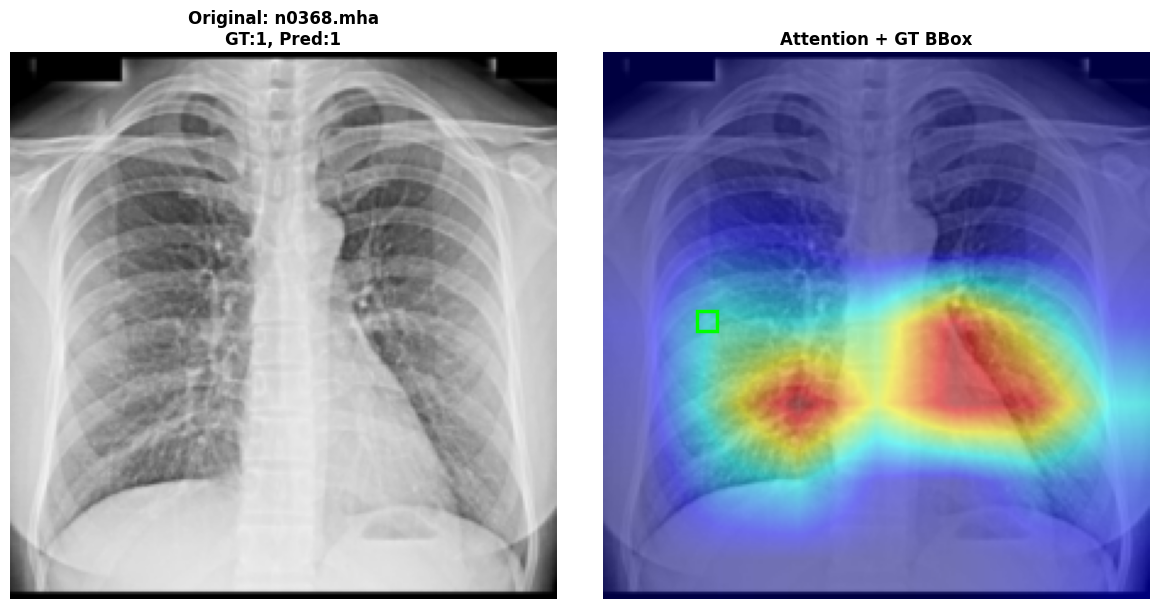


Displayed GradCAM visualizations for 2 patient(s)


In [20]:
# ============================================================================
# LOAD PRETRAINED RESNET-50 BINARY MODEL FOR GRADCAM
# ============================================================================

print("\nLoading pretrained ResNet-50 binary model...")

from torchvision import models
import torch
import timm
import torch.nn.functional as F
import cv2
import numpy as np

# Create model instance
gradcam_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
gradcam_model = gradcam_model.to(device)

# Load checkpoint
checkpoint_path = "./resnet-50_binary.pth"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

if 'model_state_dict' in checkpoint:
    gradcam_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Previous val_acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    gradcam_model.load_state_dict(checkpoint)
    print("Loaded model weights")

gradcam_model.eval()
print("✓ ResNet-50 binary model loaded for GradCAM visualization")

# ============================================================================
# GRADCAM IMPLEMENTATION
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, class_idx=None):
        """Generate GradCAM heatmap"""
        # Forward pass
        model_output = self.model(input_image)
        
        if class_idx is None:
            class_idx = model_output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = model_output[0, class_idx]
        class_score.backward()
        
        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()

def apply_colormap_on_image(org_img, activation_map, colormap=cv2.COLORMAP_JET, alpha=0.5):
    """Apply heatmap overlay on image"""
    # Resize heatmap to match image size
    heatmap = cv2.resize(activation_map, (org_img.shape[1], org_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Convert org_img to uint8 if needed
    if org_img.dtype != np.uint8:
        org_img = np.uint8(255 * org_img)
    
    # Superimpose heatmap on image
    overlayed_img = cv2.addWeighted(heatmap, alpha, org_img, 1 - alpha, 0)
    
    return overlayed_img

def denormalize_image(img_tensor):
    """Denormalize image tensor"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# ============================================================================
# VISUALIZE GRADCAM FOR SPECIFIC PATIENTS
# ============================================================================

def visualize_gradcam_specific_patients(model, dataset, df, device, patient_names):
    """Visualize GradCAM for specific patient names"""
    model.eval()
    
    # Get the last convolutional layer of ResNet50
    target_layer = model.layer4[-1]
    
    # Initialize GradCAM
    gradcam = GradCAM(model, target_layer)
    
    print(f"\nSearching for specific patients: {patient_names}")
    
    # Find indices for specific patients
    patient_indices = {}
    for i in range(len(dataset)):
        img_name = df.iloc[i]['img_name']
        if img_name in patient_names and img_name not in patient_indices:
            patient_indices[img_name] = i
    
    # Check which patients were found
    found_patients = list(patient_indices.keys())
    missing_patients = [p for p in patient_names if p not in found_patients]
    
    if missing_patients:
        print(f"⚠ Warning: Could not find these patients in dataset: {missing_patients}")
    
    if not found_patients:
        print("❌ None of the specified patients were found in the dataset!")
        return
    
    print(f"✓ Found {len(found_patients)} patient(s): {found_patients}\n")
    
    for patient_name in found_patients:
        # Get the index for this patient
        idx = patient_indices[patient_name]
        img, label, _ = dataset[idx]
        
        print(f"Patient: {patient_name}")
        
        # Find ALL bboxes for this patient from the dataframe
        patient_rows = df[df['img_name'] == patient_name]
        all_bboxes = []
        
        # Get original image dimensions
        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            img_width = 1024
            img_height = 1024
        
        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                # Normalize bbox coordinates to [0, 1]
                x_norm = row['x'] / img_width
                y_norm = row['y'] / img_height
                w_norm = row['width'] / img_width
                h_norm = row['height'] / img_height
                
                bbox_tensor = torch.tensor([x_norm, y_norm, w_norm, h_norm], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, {row['width']:.0f}, {row['height']:.0f}]")
        
        print(f"Found {len(all_bboxes)} nodule(s)")
        print(f"Ground truth label: {'Nodule' if label == 1 else 'No Nodule'}")
        
        # Get prediction and GradCAM
        image_batch = img.unsqueeze(0).to(device)
        class_logits = model(image_batch)
        
        probs = torch.softmax(class_logits, dim=1)
        pred_class = class_logits.argmax(1).item()
        pred_prob = probs[0, pred_class].item()
        
        print(f"Prediction: {'Nodule' if pred_class == 1 else 'No Nodule'} (confidence: {pred_prob:.3f})")
        
        # Generate GradCAM
        cam = gradcam.generate_cam(image_batch, class_idx=pred_class)
        
        # Denormalize image
        img_display = denormalize_image(img).permute(1, 2, 0).numpy()
        img_display_uint8 = np.uint8(255 * img_display)
        
        # Apply colormap
        overlayed_img = apply_colormap_on_image(img_display_uint8, cam, alpha=0.5)
        
        # Create figure with 2 columns: Original + GradCAM with BBoxes
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # Plot 1: Original Image
        axes[0].imshow(img_display)
        axes[0].set_title(
            f'Original: {patient_name}\nGT:{label}, Pred:{pred_class}',
            fontsize=12, fontweight='bold'
        )
        axes[0].axis('off')
        
        # Plot 2: GradCAM with ALL bboxes
        axes[1].imshow(overlayed_img)
        
        # Draw all bboxes
        for bbox in all_bboxes:
            x, y, w, h = bbox.numpy()
            x_pix = x * IMAGE_SIZE
            y_pix = y * IMAGE_SIZE
            w_pix = w * IMAGE_SIZE
            h_pix = h * IMAGE_SIZE
            
            rect = plt.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                fill=False, edgecolor='lime', linewidth=2.5
            )
            axes[1].add_patch(rect)
        
        axes[1].set_title(
            'Attention + GT BBox',
            fontsize=12, fontweight='bold'
        )
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        print()  # Empty line for readability
    
    print(f"{'='*80}")
    print(f"Displayed GradCAM visualizations for {len(found_patients)} patient(s)")
    print(f"{'='*80}")

# ============================================================================
# RUN VISUALIZATION FOR SPECIFIC PATIENTS
# ============================================================================

print("\n" + "=" * 80)
print("GRADCAM VISUALIZATION FOR SPECIFIC PATIENTS")
print("=" * 80)

# Specify the patients you want to visualize
target_patients = ['n0368.mha', 'n0315.mha']

visualize_gradcam_specific_patients(gradcam_model, test_dataset, test_df, device, target_patients)

Validation: 100%|██████████| 50/50 [00:14<00:00,  3.55it/s]


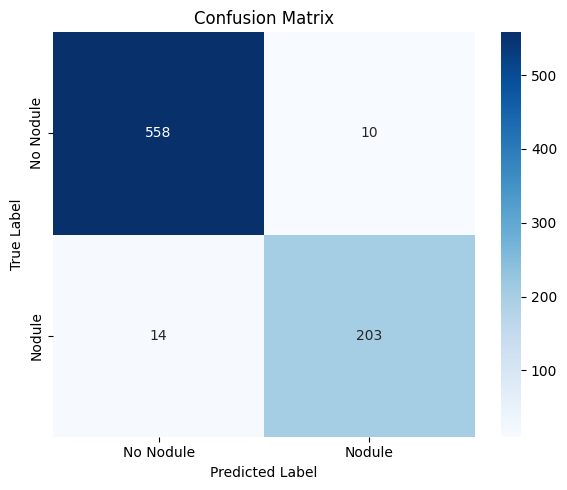

✓ Saved: confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_rec, test_f1, test_auc = validate(
    model, test_loader, criterion_cls, criterion_bbox, device, BBOX_LOSS_WEIGHT
)

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_labels = ['No Nodule', 'Nodule']

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
print("✓ Saved: confusion_matrix.png")


In [28]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
best_model_path = 'best_resnet_nodule_model(NEW).pth'
model = ResNetWithBBox(num_classes=2, pretrained=False)
model = model.to(device)
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_rec, test_f1, test_auc = validate(
    model, test_loader, criterion_cls, criterion_bbox, device, BBOX_LOSS_WEIGHT
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")

print(f"\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:11<00:00,  4.54it/s]


Test Loss: 0.1040
Test Accuracy: 96.94%
Test Precision: 0.9531
Test Recall: 0.9355
Test F1-score: 0.9442
Test ROC AUC: 0.9926

TEST SET RESULTS
Test Loss: 0.1040
Test Accuracy: 96.94%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.98      0.98      0.98       568
      Nodule       0.95      0.94      0.94       217

    accuracy                           0.97       785
   macro avg       0.96      0.96      0.96       785
weighted avg       0.97      0.97      0.97       785


Confusion Matrix:
[[558  10]
 [ 14 203]]
